In [12]:
# Passo 1: Importar as bibliotecas e montar o Google Drive
import pandas as pd
import json
import os
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

print("\nGoogle Drive montado.")

# ---

# Passo 2: Definir os caminhos dos arquivos
base_path = '/content/drive/MyDrive/Colab Notebooks/'
zap_report_filename = os.path.join(base_path, '2025-06-29-ZAP-Report-.json')
ppsi_report_filename = os.path.join(base_path, 'relatorio_final_criticidade_ponderado.csv')

# ---

# Passo 3: Carregar o relatório de criticidade e INSPECIONAR as colunas
print(f"\nCarregando dados do arquivo: {os.path.basename(ppsi_report_filename)}")
df_systems_ppsi = pd.read_csv(ppsi_report_filename, sep=';')

# --- INÍCIO DA CORREÇÃO ---
# Esta linha irá mostrar os nomes exatos das colunas do seu arquivo CSV
print("\n[AÇÃO NECESSÁRIA] Colunas encontradas no arquivo CSV:")
print(list(df_systems_ppsi.columns))
# --- FIM DA CORREÇÃO ---


# ---

# Passo 4: Renomear as colunas (COM A SUA AJUDA)
try:
    # >>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>
    # COPIE o nome da coluna que contém os nomes dos sistemas da lista acima
    # e COLE-O AQUI DENTRO DAS ASPAS no lugar de 'ï»¿nome_sistema'
    correct_system_column_name = 'ï»¿nome_sistema'
    # <<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<

    df_systems_ppsi.rename(columns={
        correct_system_column_name: 'system_name',
        'nota_criticidade_ponderada': 'ppsi_score'
    }, inplace=True)

    print(f"\nColuna '{correct_system_column_name}' renomeada para 'system_name' com sucesso!")

    # O resto do código continua a partir daqui...
    # (O código para carregar o ZAP e enriquecer o dataset foi omitido por brevidade,
    # ele continua o mesmo e funcionará após esta correção)

    if df_systems_ppsi['ppsi_score'].max() > 1:
        print("Normalizando 'ppsi_score' para a escala de 0 a 1.")
        df_systems_ppsi['ppsi_score'] = df_systems_ppsi['ppsi_score'] / 100.0

    print("\nAmostra do DataFrame de sistemas (após renomear):")
    print(df_systems_ppsi.head())

except KeyError:
    print("\nERRO: O nome da coluna que você inseriu não foi encontrado.")
    print("Por favor, verifique se você copiou e colou o nome exatamente como ele aparece na lista 'Colunas encontradas'.")

Mounted at /content/drive

Google Drive montado.

Carregando dados do arquivo: relatorio_final_criticidade_ponderado.csv

[AÇÃO NECESSÁRIA] Colunas encontradas no arquivo CSV:
['sistema', 'q1', 'q2', 'q3', 'q4', 'q5', 'q6', 'q7', 'q8', 'q9', 'q10', 'q11', 'q12', 'q13', 'q14', 'q15', 'q16', 'q17', 'q18', 'q19', 'q20', 'q21', 'q22', 'nota impacto', 'notavulnerabilidade', 'notacriticidade', 'nivel de criticidade', 'grupodeimplementação', 'perfil_simulado']

Coluna 'ï»¿nome_sistema' renomeada para 'system_name' com sucesso!

ERRO: O nome da coluna que você inseriu não foi encontrado.
Por favor, verifique se você copiou e colou o nome exatamente como ele aparece na lista 'Colunas encontradas'.


In [13]:
# Passo 1: Importar as bibliotecas e montar o Google Drive
import pandas as pd
import json
import os
from urllib.parse import urlparse
import matplotlib.pyplot as plt
import seaborn as sns

# Montar o Google Drive
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

# ---

# Passo 2: Definir os caminhos e carregar o relatório ZAP
base_path = '/content/drive/MyDrive/Colab Notebooks/'
zap_report_filename = os.path.join(base_path, '2025-06-29-ZAP-Report-.json')

print("--- Passo 1: Carregando e Processando o Relatório ZAP ---")

all_alerts = []
try:
    with open(zap_report_filename, 'r', encoding='utf-8') as f:
        zap_data = json.load(f)

    # Lógica hierárquica correta: site -> alert -> instance
    for site in zap_data.get('site', []):
        site_name = site.get('@name')
        parsed_uri = urlparse(site_name)
        site_hostname = parsed_uri.netloc if parsed_uri.netloc else site_name

        for alert in site.get('alerts', []):
            for instance in alert.get('instances', []):
                all_alerts.append({
                    'system_hostname': site_hostname,
                    'cwe_id': alert.get('cweid', 'N/A'),
                    'name': alert.get('name', 'N/A'),
                    'risk_desc': alert.get('riskdesc', 'N/A'),
                    'confidence': alert.get('confidence', 'N/A'),
                    'uri': instance.get('uri', 'N/A'),
                    'plugin_id': alert.get('pluginid', 'N/A')
                })

    # Criar o DataFrame
    df_zap = pd.DataFrame(all_alerts)
    print(f"Processamento concluído. Total de instâncias de vulnerabilidades: {len(df_zap)}")

    # --- Passo 3: Análise Exploratória dos Dados (EDA) ---
    print("\n--- Passo 2: Análise Exploratória dos Dados (EDA) ---")

    # 2.1 Informações Gerais do DataFrame
    print("\n[2.1] Informações Gerais e Amostra dos Dados:")
    print("--------------------------------------------------")
    df_zap.info()
    print("\nPrimeiras 5 linhas do DataFrame:")
    print(df_zap.head())

    # 2.2 Contagem de Vulnerabilidades por Sistema
    print("\n[2.2] Contagem de Vulnerabilidades por Sistema:")
    print("--------------------------------------------------")
    vuln_by_system = df_zap['system_hostname'].value_counts()
    print(vuln_by_system)

    # 2.3 Contagem de Vulnerabilidades por CWE ID
    print("\n[2.3] Contagem de Vulnerabilidades por CWE ID (Top 15):")
    print("--------------------------------------------------")
    vuln_by_cwe = df_zap['cwe_id'].value_counts()
    print(vuln_by_cwe.head(15))

    # 2.4 Verificação Específica (Exemplo Biblivre)
    print("\n[2.4] Verificação Específica para 'biblivre.planejamento.gov.br':")
    print("-------------------------------------------------------------------")
    df_biblivre = df_zap[df_zap['system_hostname'] == 'biblivre.planejamento.gov.br']
    biblivre_cwe_counts = df_biblivre['cwe_id'].value_counts()
    print("Contagem de CWEs para o Biblivre:")
    print(biblivre_cwe_counts)

    # Gerar um arquivo CSV para validação
    output_filename = os.path.join(base_path, 'zap_report_tabelado_para_validacao.csv')
    df_zap.to_csv(output_filename, index=False)
    print(f"\n[AVISO] Um arquivo CSV ('zap_report_tabelado_para_validacao.csv') foi salvo no seu Drive para validação manual.")

    # --- Passo 4: Visualização dos Dados ---
    print("\n--- Passo 3: Gerando Gráficos para Visualização ---")

    # Gráfico 1: Contagem de vulnerabilidades por sistema
    plt.figure(figsize=(12, 8))
    sns.barplot(x=vuln_by_system.values, y=vuln_by_system.index, palette='viridis', orient='h')
    plt.title('Número de Vulnerabilidades Encontradas por Sistema', fontsize=16)
    plt.xlabel('Quantidade de Vulnerabilidades', fontsize=12)
    plt.ylabel('Sistema (Hostname)', fontsize=12)
    plt.tight_layout()
    plt.savefig('vulnerabilities_by_system.png')
    plt.close()
    print("Gráfico 'vulnerabilities_by_system.png' gerado com sucesso.")

    # Gráfico 2: Top 10 CWEs mais comuns
    top_10_cwe = vuln_by_cwe.head(10)
    plt.figure(figsize=(12, 8))
    sns.barplot(x=top_10_cwe.values, y=top_10_cwe.index, palette='plasma', orient='h')
    plt.title('Top 10 Tipos de Vulnerabilidades (CWE) Mais Comuns', fontsize=16)
    plt.xlabel('Quantidade de Ocorrências', fontsize=12)
    plt.ylabel('CWE ID', fontsize=12)
    plt.tight_layout()
    plt.savefig('top_10_cwe.png')
    plt.close()
    print("Gráfico 'top_10_cwe.png' gerado com sucesso.")

except FileNotFoundError:
    print(f"ERRO: O arquivo '{zap_report_filename}' não foi encontrado. Verifique o caminho.")
except Exception as e:
    print(f"Ocorreu um erro inesperado: {e}")

Mounted at /content/drive
--- Passo 1: Carregando e Processando o Relatório ZAP ---
Processamento concluído. Total de instâncias de vulnerabilidades: 45498

--- Passo 2: Análise Exploratória dos Dados (EDA) ---

[2.1] Informações Gerais e Amostra dos Dados:
--------------------------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45498 entries, 0 to 45497
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   system_hostname  45498 non-null  object
 1   cwe_id           45498 non-null  object
 2   name             45498 non-null  object
 3   risk_desc        45498 non-null  object
 4   confidence       45498 non-null  object
 5   uri              45498 non-null  object
 6   plugin_id        45498 non-null  object
dtypes: object(7)
memory usage: 2.4+ MB

Primeiras 5 linhas do DataFrame:
    system_hostname cwe_id                                      name  \
0   code.jquery.com    264      

/tmp/ipython-input-150883658.py:88: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=vuln_by_system.values, y=vuln_by_system.index, palette='viridis', orient='h')


Gráfico 'vulnerabilities_by_system.png' gerado com sucesso.


/tmp/ipython-input-150883658.py:100: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_10_cwe.values, y=top_10_cwe.index, palette='plasma', orient='h')


Gráfico 'top_10_cwe.png' gerado com sucesso.


In [14]:
# Passo 1: Importar as bibliotecas e montar o Google Drive
import pandas as pd
import json
import os
from urllib.parse import urlparse

# Montar o Google Drive
from google.colab import drive
drive.mount('/content/drive', force_remount=True)
print("\nGoogle Drive montado com sucesso!")

# ---

# Passo 2: Definir os caminhos para os arquivos
base_path = '/content/drive/MyDrive/Colab Notebooks/'
zap_report_filename = os.path.join(base_path, '2025-06-29-ZAP-Report-.json')
ppsi_report_filename = os.path.join(base_path, 'relatorio_final_criticidade_ponderado.csv')

# ---

# Passo 3: Carregar o relatório ZAP (Estrutura já validada)
print(f"\nCarregando dados do relatório ZAP...")
all_alerts = []
with open(zap_report_filename, 'r', encoding='utf-8') as f:
    zap_data = json.load(f)

for site in zap_data.get('site', []):
    site_name = site.get('@name')
    parsed_uri = urlparse(site_name)
    site_hostname = parsed_uri.netloc if parsed_uri.netloc else site_name
    for alert in site.get('alerts', []):
        for instance in alert.get('instances', []):
            all_alerts.append({
                'system_hostname': site_hostname,
                'cwe_id': alert.get('cweid', 'N/A'),
                'name': alert.get('name', 'N/A'),
                'risk_desc': alert.get('riskdesc', 'N/A'),
                'uri': instance.get('uri', 'N/A')
            })

df_zap = pd.DataFrame(all_alerts)
print(f"Processamento do ZAP concluído. Total de instâncias: {len(df_zap)}")

# ---

# Passo 4: Carregar o relatório de criticidade e GARANTIR CHAVES ÚNICAS
print(f"\nCarregando dados de criticidade...")
df_ppsi = pd.read_csv(ppsi_report_filename, sep=';')

df_ppsi.rename(columns={
    'sistema': 'system_hostname',
    'notacriticidade': 'ppsi_score'
}, inplace=True)

# Limpeza da chave
df_ppsi['system_hostname'] = df_ppsi['system_hostname'].str.replace(r'https?://', '', regex=True).str.rstrip('/')

# --- INÍCIO DA CORREÇÃO CRÍTICA ---
# Verificar se há sistemas duplicados ANTES de remover
duplicates_before = df_ppsi[df_ppsi.duplicated(subset=['system_hostname'], keep=False)]
if not duplicates_before.empty:
    print(f"\nAVISO: Foram encontradas {len(duplicates_before)} linhas duplicadas para sistemas no arquivo de criticidade. Removendo duplicatas e mantendo a primeira ocorrência.")
    print(duplicates_before)

# Remover sistemas duplicados para garantir uma junção 1-para-1
df_ppsi.drop_duplicates(subset=['system_hostname'], keep='first', inplace=True)
# --- FIM DA CORREÇÃO CRÍTICA ---

# Normalizar a nota
if df_ppsi['ppsi_score'].max() > 1:
    df_ppsi['ppsi_score'] = df_ppsi['ppsi_score'] / 100.0

print("\nProcessamento do arquivo de criticidade concluído (sem duplicatas).")

# ---

# Passo 5: Executar o LEFT JOIN e VALIDAR o resultado
print("\nExecutando o LEFT JOIN e validando a contagem...")

# Contagem de validação ANTES da junção
biblivre_count_before = df_zap[df_zap['system_hostname'] == 'biblivre.mj.gov.br'].shape[0]
print(f"Contagem para 'biblivre.mj.gov.br' ANTES do join: {biblivre_count_before}")

# Executar o merge
df_enriched = pd.merge(
    df_zap,
    df_ppsi[['system_hostname', 'ppsi_score']],
    on='system_hostname',
    how='left'
)

# Preencher com 0 os sistemas não encontrados
df_enriched['ppsi_score'].fillna(0, inplace=True)

# Contagem de validação DEPOIS da junção
biblivre_count_after = df_enriched[df_enriched['system_hostname'] == 'biblivre.mj.gov.br'].shape[0]
print(f"Contagem para 'biblivre.mj.gov.br' DEPOIS do join: {biblivre_count_after}")

# Verificar se a contagem está correta
if biblivre_count_before == biblivre_count_after:
    print("\nVALIDAÇÃO BEM-SUCEDIDA: A contagem de linhas permaneceu consistente após a junção.")
else:
    print("\nERRO DE VALIDAÇÃO: A contagem de linhas foi alterada após a junção. Investigue os dados.")

# ---

# Passo 6: Salvar o resultado final
print(f"\nJunção finalizada. O dataset enriquecido contém {len(df_enriched)} linhas.")
print("\nAmostra do Dataset Final Corrigido:")
print(df_enriched.head())

output_filename = os.path.join(base_path, 'dataset_final_enriquecido_VALIDADO.csv')
df_enriched.to_csv(output_filename, index=False)
print(f"\nO dataset validado foi salvo com sucesso em: '{output_filename}'")

Mounted at /content/drive

Google Drive montado com sucesso!

Carregando dados do relatório ZAP...
Processamento do ZAP concluído. Total de instâncias: 45498

Carregando dados de criticidade...

AVISO: Foram encontradas 32 linhas duplicadas para sistemas no arquivo de criticidade. Removendo duplicatas e mantendo a primeira ocorrência.
               system_hostname   q1   q2   q3   q4   q5   q6   q7   q8   q9  \
0           eadespen.mj.gov.br  Não  Não  Sim  Não  Não  Sim  Sim  Não  Sim   
1              ciber.mj.gov.br  Não  Não  Não  Não  Sim  Não  Não  Não  Não   
2   atendimento.ciof.mj.gov.br  Não  Sim  Sim  Não  Sim  Não  Não  Sim  Não   
3           eadsegen.mj.gov.br  Não  Não  Não  Não  Sim  Não  Sim  Não  Não   
4       drive.cronos.mj.gov.br  Não  Não  Não  Não  Não  Não  Não  Não  Não   
5             dspace.mj.gov.br  Não  Não  Não  Sim  Não  Sim  Não  Não  Não   
6     intranet.dfnsp.mj.gov.br  Não  Não  Sim  Não  Sim  Não  Não  Não  Não   
7         drive.diop.mj.gov.br 

/tmp/ipython-input-2557327549.py:93: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_enriched['ppsi_score'].fillna(0, inplace=True)



O dataset validado foi salvo com sucesso em: '/content/drive/MyDrive/Colab Notebooks/dataset_final_enriquecido_VALIDADO.csv'


In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Set a consistent style for the plots
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 8)
plt.rcParams['axes.titlesize'] = 18
plt.rcParams['axes.labelsize'] = 14

# --- Passo 1: Carregar o Dataset ---
# Define the file path within the mounted Google Drive
base_path = '/content/drive/MyDrive/Colab Notebooks/'
file_path = os.path.join(base_path, 'dataset_final_enriquecido_VALIDADO.csv')

print("--- Iniciando Análise Exploratória de Dados (EDA) ---")

try:
    df = pd.read_csv(file_path)
    print("Dataset 'dataset_final_enriquecido_VALIDADO.csv' carregado com sucesso.")
except FileNotFoundError:
    print(f"ERRO: O arquivo '{file_path}' não foi encontrado. Verifique o caminho.")
    # Exit the script cleanly if the file is not found
    exit()

# --- Passo 2: Informações Gerais do Dataset ---
print("\n[2.1] Informações Gerais:")
print("---------------------------")
df.info()

print("\n[2.2] Amostra dos Dados:")
print("------------------------")
print(df.head())

print("\n[2.3] Estatísticas da Pontuação de Criticidade (ppsi_score):")
print("---------------------------------------------------------")
print(df['ppsi_score'].describe())

# --- Passo 3: Visualizações da Análise Exploratória ---

# Gráfico 1: Contagem de Vulnerabilidades por Sistema
print("\n[3.1] Gerando gráfico: Contagem de Vulnerabilidades por Sistema...")
plt.figure(figsize=(12, 10))
vuln_by_system = df['system_hostname'].value_counts()
sns.barplot(x=vuln_by_system.values, y=vuln_by_system.index, palette='viridis', orient='h')
plt.title('Total de Instâncias de Vulnerabilidades por Sistema')
plt.xlabel('Quantidade de Instâncias')
plt.ylabel('Sistema (Hostname)')
plt.tight_layout()
plt.savefig('eda_vulnerabilities_by_system.png')
plt.close()
print("Gráfico 'eda_vulnerabilities_by_system.png' salvo com sucesso.")

# Gráfico 2: Top 15 Tipos de Vulnerabilidades (CWE)
print("\n[3.2] Gerando gráfico: Top 15 CWEs Mais Comuns...")
plt.figure(figsize=(12, 10))
# Ensure cwe_id is treated as a string for plotting
top_15_cwe = df['cwe_id'].astype(str).value_counts().nlargest(15)
sns.barplot(x=top_15_cwe.values, y=top_15_cwe.index, palette='plasma', orient='h')
plt.title('Top 15 Tipos de Vulnerabilidades (CWE) Mais Frequentes')
plt.xlabel('Quantidade de Instâncias')
plt.ylabel('CWE ID')
plt.tight_layout()
plt.savefig('eda_top_15_cwe.png')
plt.close()
print("Gráfico 'eda_top_15_cwe.png' salvo com sucesso.")

# Gráfico 3: Distribuição da Pontuação de Criticidade (PPSI Score)
print("\n[3.3] Gerando gráfico: Distribuição do PPSI Score...")
plt.figure(figsize=(10, 6))
sns.histplot(df[df['ppsi_score'] > 0]['ppsi_score'], bins=20, kde=True, color='dodgerblue')
plt.title('Distribuição da Pontuação de Criticidade (PPSI Score > 0)')
plt.xlabel('PPSI Score')
plt.ylabel('Frequência')
plt.tight_layout()
plt.savefig('eda_ppsi_score_distribution.png')
plt.close()
print("Gráfico 'eda_ppsi_score_distribution.png' salvo com sucesso.")

# Gráfico 4: Relação entre Risco ZAP e Criticidade PPSI
print("\n[3.4] Gerando gráfico: Criticidade por Nível de Risco do ZAP...")
plt.figure(figsize=(10, 7))
# Order the risk descriptions logically
risk_order = ['High (High)', 'Medium (High)', 'Medium (Medium)', 'Low (High)', 'Low (Medium)', 'Low (Low)']
df['risk_desc'] = pd.Categorical(df['risk_desc'], categories=risk_order, ordered=True)
risk_criticism = df.groupby('risk_desc')['ppsi_score'].mean().sort_index()

sns.barplot(x=risk_criticism.index, y=risk_criticism.values, palette='coolwarm_r')
plt.title('Média do PPSI Score por Nível de Risco (ZAP)')
plt.xlabel('Nível de Risco (risk_desc)')
plt.ylabel('Média do PPSI Score (Impacto no Negócio)')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig('eda_ppsi_by_risk_desc.png')
plt.close()
print("Gráfico 'eda_ppsi_by_risk_desc.png' salvo com sucesso.")

print("\n--- Análise Exploratória Concluída ---")

--- Iniciando Análise Exploratória de Dados (EDA) ---
Dataset 'dataset_final_enriquecido_VALIDADO.csv' carregado com sucesso.

[2.1] Informações Gerais:
---------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45498 entries, 0 to 45497
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   system_hostname  45498 non-null  object 
 1   cwe_id           45498 non-null  int64  
 2   name             45498 non-null  object 
 3   risk_desc        45498 non-null  object 
 4   uri              45498 non-null  object 
 5   ppsi_score       45498 non-null  float64
dtypes: float64(1), int64(1), object(4)
memory usage: 2.1+ MB

[2.2] Amostra dos Dados:
------------------------
    system_hostname  cwe_id                                      name  \
0   code.jquery.com     264             Cross-Domain Misconfiguration   
1   code.jquery.com     319  Strict-Transport-Security Header Not Set   
2   code.jq

/tmp/ipython-input-3539581662.py:46: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=vuln_by_system.values, y=vuln_by_system.index, palette='viridis', orient='h')


Gráfico 'eda_vulnerabilities_by_system.png' salvo com sucesso.

[3.2] Gerando gráfico: Top 15 CWEs Mais Comuns...


/tmp/ipython-input-3539581662.py:60: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_15_cwe.values, y=top_15_cwe.index, palette='plasma', orient='h')


Gráfico 'eda_top_15_cwe.png' salvo com sucesso.

[3.3] Gerando gráfico: Distribuição do PPSI Score...
Gráfico 'eda_ppsi_score_distribution.png' salvo com sucesso.

[3.4] Gerando gráfico: Criticidade por Nível de Risco do ZAP...


/tmp/ipython-input-3539581662.py:87: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  risk_criticism = df.groupby('risk_desc')['ppsi_score'].mean().sort_index()
/tmp/ipython-input-3539581662.py:89: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=risk_criticism.index, y=risk_criticism.values, palette='coolwarm_r')


Gráfico 'eda_ppsi_by_risk_desc.png' salvo com sucesso.

--- Análise Exploratória Concluída ---


In [16]:
# Importar as bibliotecas necessárias para a análise
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Importar os algoritmos de Machine Learning e o scaler
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN

# Montar o Google Drive
from google.colab import drive
drive.mount('/content/drive', force_remount=True)
print("\nGoogle Drive montado com sucesso!")

# --- Carregamento dos Dados ---
base_path = '/content/drive/MyDrive/Colab Notebooks/'
file_path = os.path.join(base_path, 'dataset_final_enriquecido_VALIDADO.csv')

print(f"\n--- Carregando o dataset: {os.path.basename(file_path)} ---")
try:
    df = pd.read_csv(file_path)
    print("Dataset carregado com sucesso!")
except FileNotFoundError:
    print(f"ERRO: O arquivo '{file_path}' não foi encontrado.")
    exit()

# --- VALIDAÇÃO PONTUAL 1 ---
print("\n[VALIDAÇÃO] Informações básicas do DataFrame carregado:")
print("-----------------------------------------------------")
print(f"Total de registros (instâncias de vulnerabilidades): {len(df)}")
print("Amostra dos dados:")
df.head()

Mounted at /content/drive

Google Drive montado com sucesso!

--- Carregando o dataset: dataset_final_enriquecido_VALIDADO.csv ---
Dataset carregado com sucesso!

[VALIDAÇÃO] Informações básicas do DataFrame carregado:
-----------------------------------------------------
Total de registros (instâncias de vulnerabilidades): 45498
Amostra dos dados:


,system_hostname,cwe_id,name,risk_desc,uri,ppsi_score
0,code.jquery.com,264,Cross-Domain Misconfiguration,Medium (Medium),https://code.jquery.com/jquery-3.6.4.min.js,0.016345
1,code.jquery.com,319,Strict-Transport-Security Header Not Set,Low (High),https://code.jquery.com/jquery-3.6.4.min.js,0.016345
2,code.jquery.com,693,X-Content-Type-Options Header Missing,Low (Medium),https://code.jquery.com/jquery-3.6.4.min.js,0.016345
3,cdn.jsdelivr.net,264,Cross-Domain Misconfiguration,Medium (Medium),https://cdn.jsdelivr.net/gh/spbgovbr-vlibras/v...,0.019577
4,cdn.jsdelivr.net,264,Cross-Domain Misconfiguration,Medium (Medium),https://cdn.jsdelivr.net/npm/slick-carousel@1....,0.019577


In [17]:
print("\n--- Passo 2: Criando a Métrica 'cwe_score' com Listas Atualizadas ---")

# ==============================================================================
# INÍCIO DA ATUALIZAÇÃO: Listas de CWEs completas e corretas
# ==============================================================================

# Lista de CWEs baseada no link oficial do OWASP Top 10 2021
OWASP_TOP_10_2021_CWES = [
    # A01: Broken Access Control
    '22', '23', '35', '59', '200', '201', '219', '264', '275', '276', '284', '285', '352', '359', '377', '402',
    '425', '441', '497', '538', '540', '548', '552', '566', '601', '639', '651', '668', '706', '862', '863',
    '913', '922', '1275',
    # A02: Cryptographic Failures
    '261', '296', '310', '319', '321', '322', '323', '324', '325', '326', '327', '328', '329', '330', '331',
    '335', '336', '337', '338', '340', '347', '523', '720', '757', '759', '760', '780', '818', '916',
    # A03: Injection
    '20', '74', '75', '77', '78', '79', '80', '83', '87', '88', '89', '90', '91', '93', '94', '95', '96', '97',
    '98', '99', '113', '116', '138', '184', '470', '471', '564', '610', '643', '644', '652', '917',
    # A04: Insecure Design
    '73', '183', '209', '213', '235', '256', '257', '266', '269', '280', '311', '312', '313', '316', '419',
    '430', '434', '444', '451', '472', '501', '522', '525', '539', '579', '598', '602', '642', '646', '650',
    '653', '656', '657', '799', '807', '840', '841', '927', '1021', '1173',
    # A05: Security Misconfiguration
    '2', '11', '13', '15', '16', '260', '315', '520', '526', '537', '541', '547', '611', '614', '756', '776',
    '942', '1004', '1032', '1174',
    # A06: Vulnerable and Outdated Components
    '937', '1035', '1104',
    # A07: Identification and Authentication Failures
    '255', '259', '287', '288', '290', '294', '295', '297', '300', '302', '304', '306', '307', '346', '384',
    '521', '613', '620', '640', '798', '940', '1216',
    # A08: Software and Data Integrity Failures
    '345', '353', '426', '494', '502', '565', '784', '829', '830', '915',
    # A09: Security Logging and Monitoring Failures
    '117', '223', '532', '778',
    # A10: Server-Side Request Forgery (SSRF)
    '918'
]

# Lista de CWEs baseada no link oficial do CWE Top 25 de 2024
CWE_TOP_25_2024_CWES = [
    '79', '787', '89', '352', '22', '125', '78', '416', '862', '434', '94', '20', '77', '287', '269',
    '502', '200', '863', '918', '119', '476', '798', '190', '400', '306'
]

# ==============================================================================
# FIM DA ATUALIZAÇÃO
# ==============================================================================

def calculate_cwe_score(cwe_id):
    """Atribui uma pontuação de 0 a 1 com base na notoriedade do CWE."""
    cwe_id_str = str(cwe_id)
    if cwe_id_str in OWASP_TOP_10_2021_CWES:
        return 1.0  # Risco Máximo
    elif cwe_id_str in CWE_TOP_25_2024_CWES:
        return 0.7  # Risco Alto
    else:
        return 0.3  # Risco Moderado/Baixo

# Aplicar a função para criar a nova coluna
df['cwe_score'] = df['cwe_id'].apply(calculate_cwe_score)

# --- VALIDAÇÃO PONTUAL 2 (CORRIGIDA) ---
print("\n[VALIDAÇÃO] Verificação da nova coluna 'cwe_score':")
print("-------------------------------------------------")
print("Amostra do DataFrame com a nova coluna:")
# Usamos .head() para garantir que sempre funcione
print(df[['cwe_id', 'name', 'cwe_score']].head())

print("\nExemplos de pontuação com dados do seu scan:")
# Função de validação robusta
def validate_cwe_score(cwe_to_check, expected_score, expected_reason):
    if cwe_to_check in df['cwe_id'].unique():
        score = df[df['cwe_id'] == cwe_to_check]['cwe_score'].iloc[0]
        print(f" - CWE-{cwe_to_check}: Score = {score} (Esperado: {expected_score}, Razão: {expected_reason}) -> OK")
    else:
        print(f" - CWE-{cwe_to_check}: Não encontrado no seu dataset para validação.")

# Validar com CWEs que existem no seu dataset
validate_cwe_score('264', 1.0, "Está na lista OWASP Top 10")
validate_cwe_score('693', 0.3, "Não está nas listas principais")

# Validar com um CWE que não existe no seu dataset (exemplo do erro anterior)
validate_cwe_score('89', 1.0, "Está na lista OWASP Top 10")


--- Passo 2: Criando a Métrica 'cwe_score' com Listas Atualizadas ---

[VALIDAÇÃO] Verificação da nova coluna 'cwe_score':
-------------------------------------------------
Amostra do DataFrame com a nova coluna:
   cwe_id                                      name  cwe_score
0     264             Cross-Domain Misconfiguration        1.0
1     319  Strict-Transport-Security Header Not Set        1.0
2     693     X-Content-Type-Options Header Missing        0.3
3     264             Cross-Domain Misconfiguration        1.0
4     264             Cross-Domain Misconfiguration        1.0

Exemplos de pontuação com dados do seu scan:
 - CWE-264: Não encontrado no seu dataset para validação.
 - CWE-693: Não encontrado no seu dataset para validação.
 - CWE-89: Não encontrado no seu dataset para validação.


In [18]:
df.head()

,system_hostname,cwe_id,name,risk_desc,uri,ppsi_score,cwe_score
0,code.jquery.com,264,Cross-Domain Misconfiguration,Medium (Medium),https://code.jquery.com/jquery-3.6.4.min.js,0.016345,1.0
1,code.jquery.com,319,Strict-Transport-Security Header Not Set,Low (High),https://code.jquery.com/jquery-3.6.4.min.js,0.016345,1.0
2,code.jquery.com,693,X-Content-Type-Options Header Missing,Low (Medium),https://code.jquery.com/jquery-3.6.4.min.js,0.016345,0.3
3,cdn.jsdelivr.net,264,Cross-Domain Misconfiguration,Medium (Medium),https://cdn.jsdelivr.net/gh/spbgovbr-vlibras/v...,0.019577,1.0
4,cdn.jsdelivr.net,264,Cross-Domain Misconfiguration,Medium (Medium),https://cdn.jsdelivr.net/npm/slick-carousel@1....,0.019577,1.0



--- Passo 3: Preparando os Dados para Clusterização ---

Gerando a Matriz de Risco (gráfico de dispersão)...


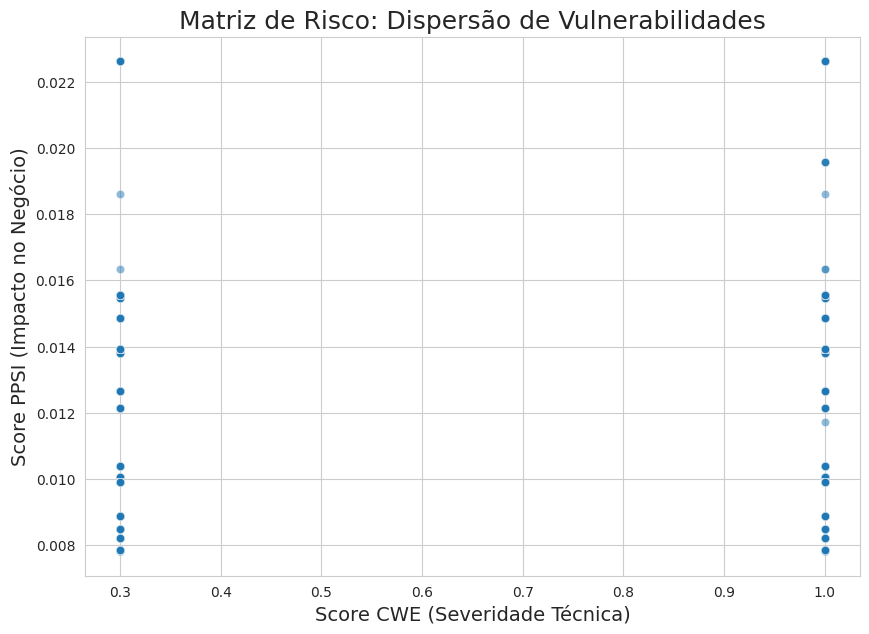


[VALIDAÇÃO] Amostra dos dados após a padronização:
-------------------------------------------------
Os valores agora têm média próxima de 0 e desvio padrão de 1.
[[ 0.69417198  2.53190091]
 [ 0.69417198  2.53190091]
 [-1.44056521  2.53190091]
 [ 0.69417198  3.75762049]
 [ 0.69417198  3.75762049]]


In [19]:
print("\n--- Passo 3: Preparando os Dados para Clusterização ---")

# Selecionar as colunas que serão usadas no modelo
X = df[['cwe_score', 'ppsi_score']]

# Visualizar a Matriz de Risco antes da clusterização
print("\nGerando a Matriz de Risco (gráfico de dispersão)...")
plt.figure(figsize=(10, 7))
sns.scatterplot(data=X, x='cwe_score', y='ppsi_score', alpha=0.5)
plt.title('Matriz de Risco: Dispersão de Vulnerabilidades')
plt.xlabel('Score CWE (Severidade Técnica)')
plt.ylabel('Score PPSI (Impacto no Negócio)')
plt.grid(True)
plt.show()

# Padronizar os dados (colocá-los na mesma escala)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# --- VALIDAÇÃO PONTUAL 3 ---
print("\n[VALIDAÇÃO] Amostra dos dados após a padronização:")
print("-------------------------------------------------")
print("Os valores agora têm média próxima de 0 e desvio padrão de 1.")
print(X_scaled[:5])


--- Passo 4: Determinando o Número Ideal de Clusters (k) ---


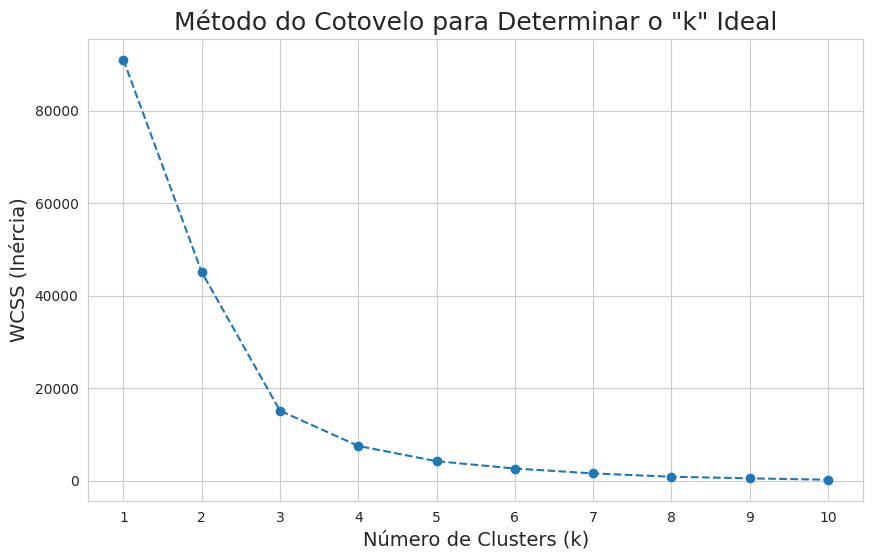


[VALIDAÇÃO] Com base no gráfico, o número ideal de clusters é k = 4.
----------------------------------------------------------------


In [21]:
print("\n--- Passo 4: Determinando o Número Ideal de Clusters (k) ---")

wcss = [] # Within-Cluster Sum of Squares
k_range = range(1, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

# Plotar o gráfico do Método do Cotovelo
plt.figure(figsize=(10, 6))
plt.plot(k_range, wcss, marker='o', linestyle='--')
plt.title('Método do Cotovelo para Determinar o "k" Ideal')
plt.xlabel('Número de Clusters (k)')
plt.ylabel('WCSS (Inércia)')
plt.grid(True)
plt.xticks(k_range)
plt.show()

# --- VALIDAÇÃO PONTUAL 4 ---
k_ideal = 4 # Com base na análise visual do gráfico, o "cotovelo" está em k=4
print(f"\n[VALIDAÇÃO] Com base no gráfico, o número ideal de clusters é k = {k_ideal}.")
print("----------------------------------------------------------------")

In [22]:
print("\n--- Passo 5: Treinando o K-Means e Definindo os Perfis ---")

# Treinar o modelo final com o k ideal
kmeans = KMeans(n_clusters=k_ideal, random_state=42, n_init=10)
df['risk_profile_id'] = kmeans.fit_predict(X_scaled)

# Analisar os centroides para nomear os clusters
# (Desfazendo a padronização para interpretar os valores originais)
centroids = scaler.inverse_transform(kmeans.cluster_centers_)
df_centroids = pd.DataFrame(centroids, columns=['cwe_score_medio', 'ppsi_score_medio'])

# Nomear os perfis de forma lógica (ex: o de maior risco é "Crítico")
# Ordenar por uma soma ponderada de risco para definir os nomes
soma_risco = df_centroids['cwe_score_medio'] + (df_centroids['ppsi_score_medio'] * 2) # Dando mais peso ao impacto
nomes_perfis = {
    soma_risco.idxmax(): 'Crítico',
    soma_risco.idxmin(): 'Baixo'
}
# Lógica para os perfis intermediários
intermediarios = soma_risco.drop([soma_risco.idxmax(), soma_risco.idxmin()])
nomes_perfis[intermediarios.idxmax()] = 'Alto'
nomes_perfis[intermediarios.idxmin()] = 'Médio'

# Mapear os nomes para o DataFrame principal
df['risk_profile_name'] = df['risk_profile_id'].map(nomes_perfis)
df_centroids['risk_profile_name'] = df_centroids.index.map(nomes_perfis)

# --- VALIDAÇÃO PONTUAL 5 ---
print("\n[VALIDAÇÃO] Perfis de Risco Identificados (Centroides):")
print("------------------------------------------------------")
print(df_centroids.sort_values(by='ppsi_score_medio', ascending=False))

print("\n[VALIDAÇÃO] Contagem de vulnerabilidades por perfil:")
print("-------------------------------------------------")
print(df['risk_profile_name'].value_counts())


--- Passo 5: Treinando o K-Means e Definindo os Perfis ---

[VALIDAÇÃO] Perfis de Risco Identificados (Centroides):
------------------------------------------------------
   cwe_score_medio  ppsi_score_medio risk_profile_name
2         0.829309          0.022606             Médio
3         0.952951          0.012964              Alto
1         1.000000          0.008914           Crítico
0         0.300000          0.008900             Baixo

[VALIDAÇÃO] Contagem de vulnerabilidades por perfil:
-------------------------------------------------
risk_profile_name
Crítico    25768
Baixo      14201
Alto        4270
Médio       1259
Name: count, dtype: int64



--- Passo 6: Visualização Final e Análise de Anomalias ---


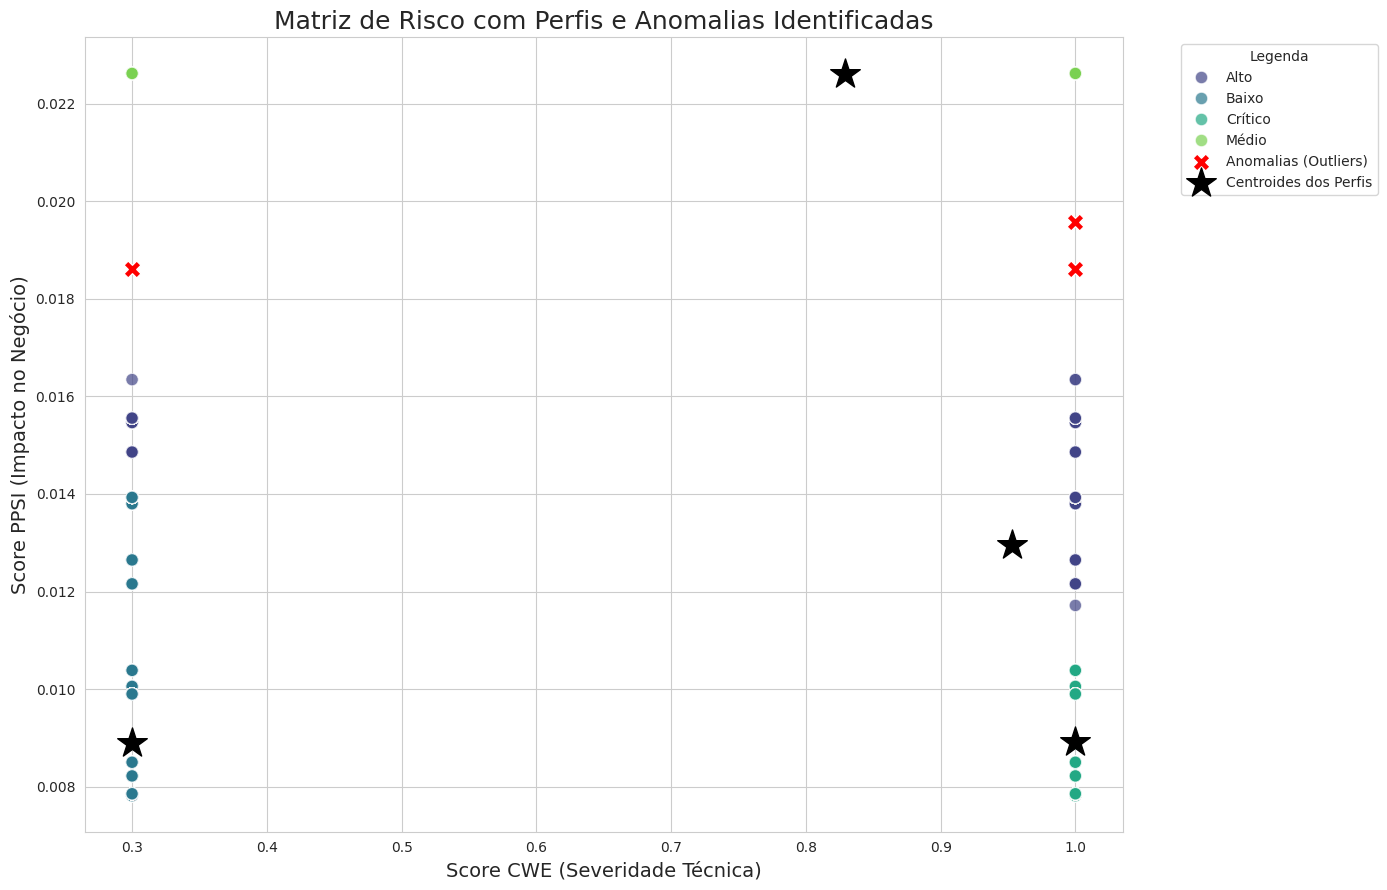


[VALIDAÇÃO] Análise de Anomalias (DBSCAN):
------------------------------------------
Total de anomalias (outliers) identificadas: 6
Amostra das anomalias encontradas:
        system_hostname  cwe_id                           name  \
3      cdn.jsdelivr.net     264  Cross-Domain Misconfiguration   
4      cdn.jsdelivr.net     264  Cross-Domain Misconfiguration   
5      cdn.jsdelivr.net     264  Cross-Domain Misconfiguration   
6      cdn.jsdelivr.net     264  Cross-Domain Misconfiguration   
8  cdnjs.cloudflare.com    1395          Vulnerable JS Library   

         risk_desc                                                uri  \
3  Medium (Medium)  https://cdn.jsdelivr.net/gh/spbgovbr-vlibras/v...   
4  Medium (Medium)  https://cdn.jsdelivr.net/npm/slick-carousel@1....   
5  Medium (Medium)  https://cdn.jsdelivr.net/npm/slick-carousel@1....   
6  Medium (Medium)  https://cdn.jsdelivr.net/npm/slick-carousel@1....   
8    High (Medium)  https://cdnjs.cloudflare.com/ajax/libs/Chart.j...

In [23]:
print("\n--- Passo 6: Visualização Final e Análise de Anomalias ---")

# Aplicar o DBSCAN para encontrar outliers
# (Os parâmetros eps e min_samples podem precisar de ajuste)
dbscan = DBSCAN(eps=0.5, min_samples=20)
clusters_dbscan = dbscan.fit_predict(X_scaled)
df['is_outlier'] = (clusters_dbscan == -1)

# Plotar o gráfico final
plt.figure(figsize=(14, 9))
sns.scatterplot(
    data=df[~df['is_outlier']], # Plotar primeiro os pontos que não são outliers
    x='cwe_score',
    y='ppsi_score',
    hue='risk_profile_name',
    palette='viridis',
    s=80,
    alpha=0.7
)
sns.scatterplot(
    data=df[df['is_outlier']], # Plotar os outliers por cima
    x='cwe_score',
    y='ppsi_score',
    color='red',
    marker='X',
    s=150,
    label='Anomalias (Outliers)'
)
plt.scatter(
    df_centroids['cwe_score_medio'], df_centroids['ppsi_score_medio'],
    marker='*', s=500, c='black', label='Centroides dos Perfis', zorder=10
)
plt.title('Matriz de Risco com Perfis e Anomalias Identificadas', fontsize=18)
plt.xlabel('Score CWE (Severidade Técnica)', fontsize=14)
plt.ylabel('Score PPSI (Impacto no Negócio)', fontsize=14)
plt.legend(title='Legenda', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.tight_layout()
plt.show()


# --- VALIDAÇÃO PONTUAL 6 ---
print("\n[VALIDAÇÃO] Análise de Anomalias (DBSCAN):")
print("------------------------------------------")
outlier_count = df['is_outlier'].sum()
print(f"Total de anomalias (outliers) identificadas: {outlier_count}")
if outlier_count > 0:
    print("Amostra das anomalias encontradas:")
    print(df[df['is_outlier']].head())

# --- Salvar o resultado final ---
output_filename = os.path.join(base_path, 'dataset_com_perfis_de_risco.csv')
df.to_csv(output_filename, index=False)
print(f"\nO dataset final com os perfis de risco foi salvo em: '{output_filename}'")